In [1]:
import os
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoProcessor, AutoModel

/Users/armaanjagirdar/glance_task/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [3]:
import os

os.environ["HF_HOME"] = "models"
MODEL_NAME = "patrickjohncyh/fashion-clip"

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 8921.00it/s]


CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1

In [4]:
from pathlib import Path

dataset_dir = Path("../dataset/images")
EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_paths = sorted([
    p for p in dataset_dir.iterdir()
    if p.suffix.lower() in EXTENSIONS
])
print(f"Found {len(image_paths)} images")

Found 3200 images


In [5]:
from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        return image, str(self.image_paths[idx])

In [6]:
from torch.utils.data import DataLoader

dataset = ImageDataset(image_paths)

def collate_fn(batch):
    images, paths = zip(*batch)
    inputs = processor(
        images=list(images),
        return_tensors="pt"
    )
    return inputs, paths

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

In [7]:
all_embeddings = []
all_paths = []

with torch.no_grad():
    for inputs, paths in tqdm(loader):
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model.get_image_features(**inputs)
        embeddings = F.normalize(outputs.pooler_output, dim=-1)

        all_embeddings.append(embeddings.cpu())

        all_paths.extend(paths)

image_embeddings = torch.cat(all_embeddings).numpy().astype(np.float32)

100%|██████████| 100/100 [00:29<00:00,  3.41it/s]


In [8]:
import hnswlib

DIM = image_embeddings.shape[1]
index = hnswlib.Index(
    space="cosine",
    dim=DIM,
)
index.init_index(
    max_elements=len(image_embeddings),
    ef_construction=200,
    M=32,
)
index.add_items(
    image_embeddings,
    np.arange(len(image_embeddings))
)
index.set_ef(100)
print(f"Indexed {len(image_embeddings)} images.")

Indexed 3200 images.


In [9]:
index.save_index("../vdb/multi_retrieve.bin")
index = hnswlib.Index(space="cosine", dim=DIM)
index.load_index("../vdb/multi_retrieve.bin")

In [11]:
@torch.no_grad()
def encode_texts(texts, batch_size=64):
    embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding text"):
        batch = texts[i:i + batch_size]

        inputs = processor(
            text=batch,
            padding=True,
            truncation=True,
            return_tensors="pt"
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model.get_text_features(**inputs)
        emb = F.normalize(outputs.pooler_output, dim=-1)
        embeddings.append(emb.cpu())

    return torch.cat(embeddings).numpy().astype(np.float32)

In [12]:
def retrieve(query, k=50):
    query_embedding = encode_texts([query])[0]
    labels, distances = index.knn_query(
        query_embedding,
        k=k,
    )

    results = []

    for idx, dist in zip(labels[0], distances[0]):
        results.append({
            "image_id": int(idx),
            "path": all_paths[idx],
            "score": float(1 - dist),
        })

    return results

In [14]:
import matplotlib.pyplot as plt

def show_results(results):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for ax, r in zip(axes, results):
        img = Image.open(r["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{r['score']:.3f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [17]:
import json

ANNOTATION_JSON = "../dataset/instances_attributes_val2020.json"

with open(ANNOTATION_JSON, "r") as f:
    data = json.load(f)

category_labels = [
    c["name"].strip().lower()
    for c in data["categories"]
]

attribute_labels = [
    a["name"].strip().lower()
    for a in data["attributes"]
]

print(f"Categories : {len(category_labels)}")
print(f"Attributes : {len(attribute_labels)}")

Categories : 46
Attributes : 294


In [18]:
style_labels = [
    "formal",
    "casual",
    "business",
    "streetwear",
    "minimalist",
    "vintage",
    "sporty",
    "bohemian",
    "luxury",
    "preppy",
    "smart casual",
    "party wear",
]

In [19]:
category_embeddings = encode_texts(category_labels)
attribute_embeddings = encode_texts(attribute_labels)
style_embeddings = encode_texts(style_labels)

Encoding text: 100%|██████████| 1/1 [00:00<00:00, 36.78it/s]


In [21]:
def semantic_head(
    embedding,
    label_embeddings,
    labels,
    top_k=10,
):
    scores = embedding @ label_embeddings.T
    idx = np.argsort(scores)[::-1][:top_k]

    return [
        {
            "label": labels[i],
            "score": float(scores[i]),
        }
        for i in idx
    ]

In [24]:
def semantic_scores(
    embeddings,
    label_embeddings,
):
    return embeddings @ label_embeddings.T

In [36]:
def retrieve_candidates(query, k=100):
    query_embedding = encode_texts([query])[0]

    labels, distances = index.knn_query(
        query_embedding,
        k=k,
    )

    candidate_ids = labels[0]

    return {
        "query_embedding": query_embedding,
        "candidate_ids": candidate_ids,
        "candidate_embeddings": image_embeddings[candidate_ids],
        "image_similarity": 1 - distances[0],
    }

In [ ]:
from collections import defaultdict

def reciprocal_rank_fusion(rankings, k=60):
    scores = defaultdict(float)
    for ranking in rankings:
        for rank, idx in enumerate(ranking):
            scores[idx] += 1.0 / (k + rank + 1)

    return scores

def rank_scores(scores):
    return np.argsort(scores)[::-1]

def top_k_mask(scores, k, normalize=True):
    masked = np.zeros_like(scores)
    idx = np.argpartition(scores, -k)[-k:]
    masked[idx] = scores[idx]
    if normalize:
        s = masked.sum()
        if s > 0:
            masked /= s
    return masked

In [58]:
TOP_K = {
    "category": 3,
    "attribute": 10,
    "style": 3,
}

HEADS = {
    "category": category_embeddings,
    "attribute": attribute_embeddings,
    "style": style_embeddings,
}

In [59]:
def semantic_scores(embeddings, label_embeddings):
    return embeddings @ label_embeddings.T

def project_query(query_embedding):

    projections = {}

    for head_name, head_embeddings in HEADS.items():
        scores = semantic_scores(
            query_embedding[None],
            head_embeddings,
        )[0]
        scores = top_k_mask(
            scores,
            TOP_K[head_name],
        )
        projections[head_name] = {
            "scores": scores,
            "active": np.flatnonzero(scores),
        }

    return projections

In [61]:
def project_candidates(candidate_embeddings):

    projections = {}

    for head_name, head_embeddings in HEADS.items():

        projections[head_name] = semantic_scores(
            candidate_embeddings,
            head_embeddings,
        )

    return projections

In [62]:
def sparse_match(candidate_scores, query_head):
    active = query_head["active"]
    if len(active) == 0:
        return np.zeros(candidate_scores.shape[0])

    return (
        candidate_scores[:, active]
        @
        query_head["scores"][active]
    )

In [63]:
def build_rankings(
    image_similarity,
    query_projection,
    candidate_projection,
):
    rankings = {
        "image": np.argsort(image_similarity)[::-1]
    }
    for head in HEADS.keys():
        scores = sparse_match(
            candidate_projection[head],
            query_projection[head],
        )
        rankings[head] = np.argsort(scores)[::-1]

    return rankings

In [64]:
from collections import defaultdict

def reciprocal_rank_fusion(rankings, k=60):
    scores = defaultdict(float)
    for ranking in rankings.values():
        for rank, idx in enumerate(ranking):
            scores[idx] += 1.0 / (k + rank + 1)
    return scores

In [65]:
def retrieve(query, k=5, rerank_k=30):

    retrieval = retrieve_candidates(query, rerank_k)
    query_projection = project_query(
        retrieval["query_embedding"]
    )
    candidate_projection = project_candidates(
        retrieval["candidate_embeddings"]
    )
    rankings = build_rankings(
        retrieval["image_similarity"],
        query_projection,
        candidate_projection,
    )
    rrf_scores = reciprocal_rank_fusion(rankings)
    final = sorted(
        rrf_scores.items(),
        key=lambda x: x[1],
        reverse=True,
    )

    results = []
    for candidate_idx, score in final[:k]:
        image_idx = retrieval["candidate_ids"][candidate_idx]
        results.append({
            "image_id": int(image_idx),
            "path": all_paths[image_idx],
            "score": float(score),
        })

    return results

Encoding text: 100%|██████████| 1/1 [00:00<00:00, 14.16it/s]


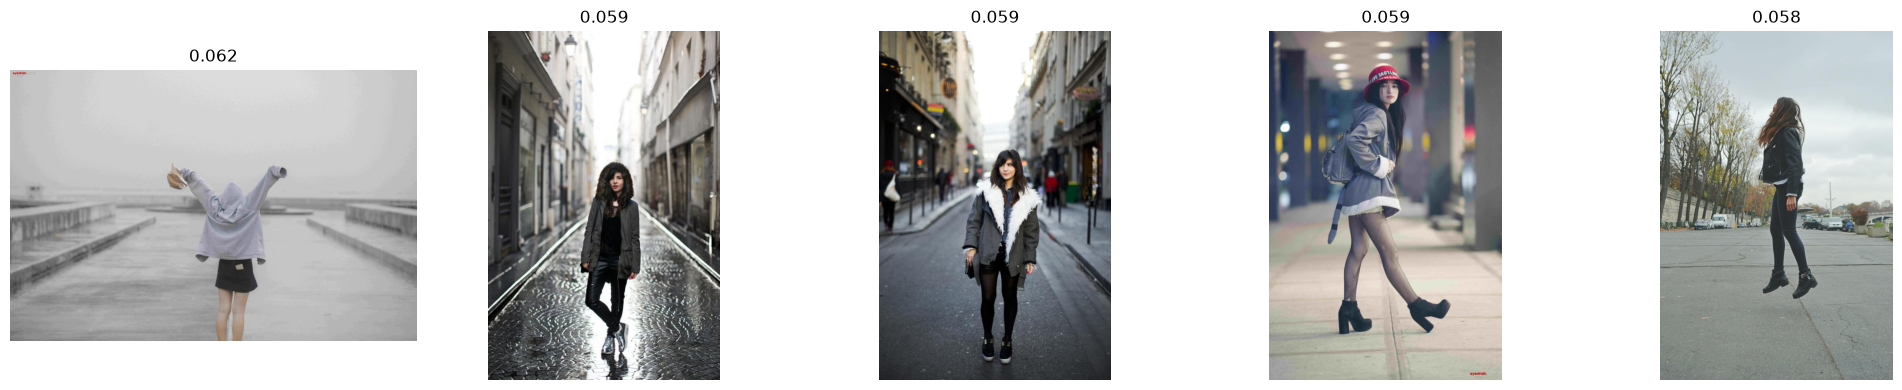

In [67]:
show_results(retrieve("cold atmosphere.", 5))